In [4]:
# Sam Brown
# sam_brown@mines.edu
# Date: 05/30/2025
# Goal: Determine ratio for each event of impulsive events to non-impulsive events (or some useful metric)

# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.signal
import math

import my_lib.funcs

# Set path to event files
evts_path = "/Users/sambrown04/Documents/SURF/Events/2010_2010Events2stas"

In [5]:
events_list = my_lib.funcs.load_evt(evts_path)

In [6]:
events_list[0].head()

,Unnamed: 0,time,la01x,la01y,la01z,la01res,la01res_avg,la02x,la02y,la02z,...,ws05res,ws05res_avg,slw1x,slw1y,slw1z,slw1res,slw1res_avg,sum_res_avg,ressum,event
0,1854301,2010-11-18 23:03:00,-269289.563340,-556078.716693,92.3913,0.564852,0.540806,-277716.670621,-560500.283508,92.8241,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.579589,2.604168,1.0
1,1854302,2010-11-18 23:03:15,-269289.565888,-556078.707728,92.3959,0.564852,0.540806,-277716.671290,-560500.273384,92.8414,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.579589,2.671480,1.0
2,1854303,2010-11-18 23:03:30,-269289.562217,-556078.722279,92.3846,0.564852,0.540806,-277716.670982,-560500.281640,92.8318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.579589,2.682214,1.0
3,1854304,2010-11-18 23:03:45,-269289.564701,-556078.723765,92.3648,0.621760,0.540806,-277716.667992,-560500.283122,92.8137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.579589,2.771749,1.0
4,1854305,2010-11-18 23:04:00,-269289.563825,-556078.719483,92.3863,0.621760,0.540806,-277716.665632,-560500.277538,92.8293,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.579589,2.771749,1.0


In [7]:
proc_events = my_lib.funcs.preprocess_events(events_list)

In [8]:
proc_events[0].head()

,la01x,la02x,la04x,la05x,la06x,la07x,la08x,la09x,la10x,time_sec
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.002548,0.000670,0.001023,0.001910,0.004177,0.003173,0.000389,0.000366,0.000678,15.0
2,0.001123,0.000361,0.004057,0.000782,0.002984,0.001622,0.000556,0.000731,0.002131,30.0
3,0.001361,0.002628,0.006945,0.002364,0.000883,0.000300,0.006129,0.002069,0.004544,45.0
4,0.000486,0.004988,0.007686,0.001503,0.002985,0.000761,0.002145,0.003407,0.001428,60.0


In [9]:
features_list = my_lib.funcs.extract_event_features(events_list)
features_list[100].head(10)

,station,pre-slip_area,slip_severity,peak_time,total_delta
0,la09x,19.205298,1.995194e-07,3645.0,0.102163
1,slw1x,48.772134,1.398927e-06,3645.0,0.424319


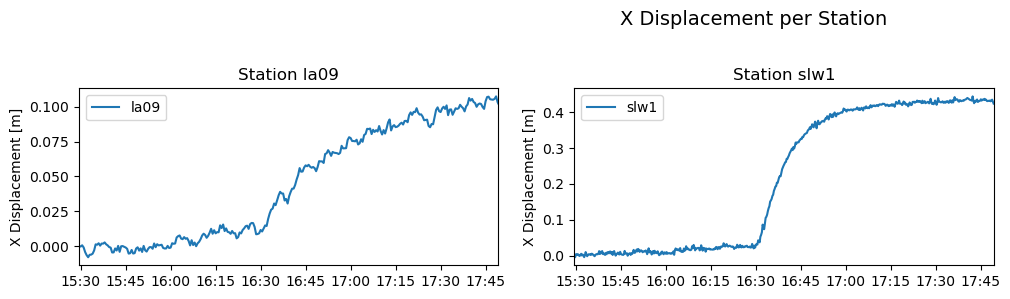

In [10]:
my_lib.funcs.plot_event(events_list[100], True)

In [11]:
# 9 * 10^-7 is appearing to be a good threshold. 1 * 10^-6 could be good as well

In [12]:
# encode each station to include 1 if slip severity is larger than 9 * 10^-7 and 0 if it is less than
for event in features_list:
    event['impulsiveInd'] = (event['slip_severity'] > 9 * 10 ** -7).astype(int) # Encode the target variable


In [61]:
features_list[418].head()

,station,pre-slip_area,slip_severity,peak_time,total_delta,impulsiveInd
0,la02x,4.503547,0.000001,750.0,0.41015,1


In [41]:
impulsive_ratios = [0]

for event in features_list:
    num_ones = (event['impulsiveInd'] == 1).sum()
    num_zeros = (event['impulsiveInd'] == 0).sum()

    # print(num_ones, num_zeros)

    total = num_zeros + num_ones

    impulsive_ratios.append(num_ones / total)
        
    

In [51]:
maxi = max(impulsive_ratios)
index = impulsive_ratios.index(maxi)
print(index)

419


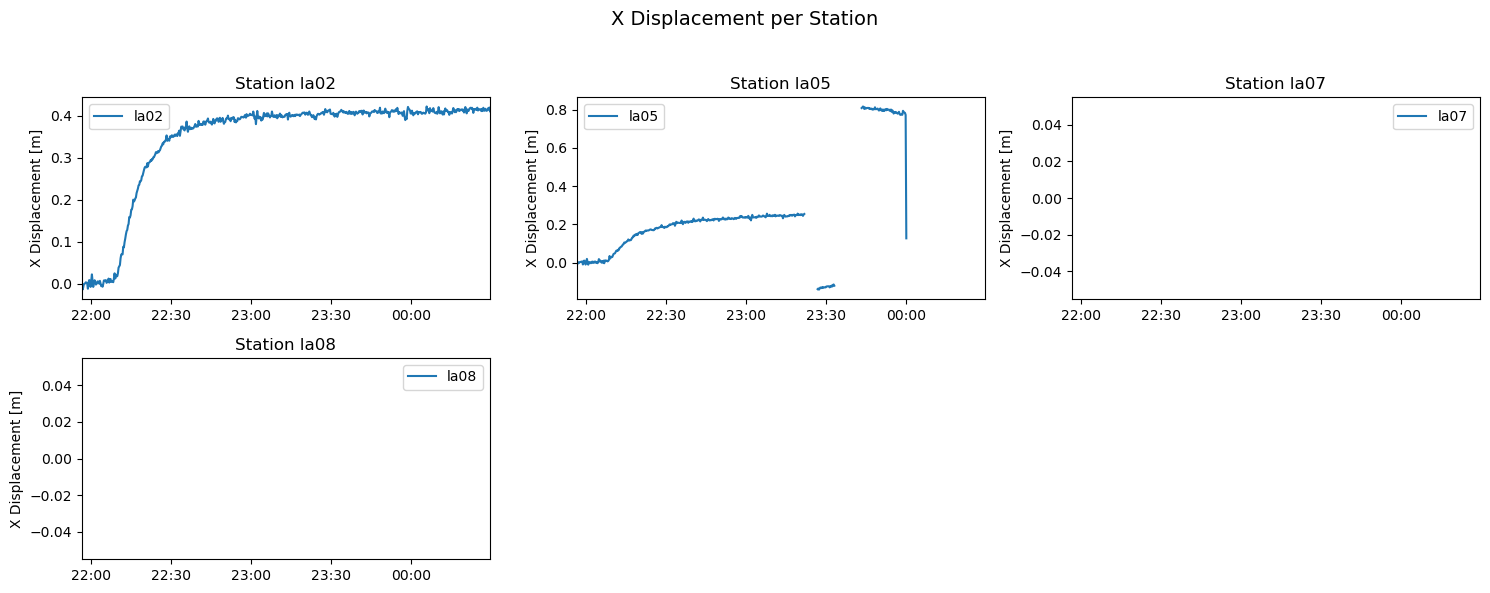

In [63]:
my_lib.funcs.plot_event(events_list[418], True)